# Analysis Tutorial for joint GBM + LLE + LAT spectral analysis using 3ML (https://threeml.readthedocs.io/en/stable/index.html)
Includes extraction of all 3 datasets, background fitting and source selection, and LAT likelihood analysis.

Should be in Fermi Conda environment on FermiBottle: `conda activate fermi` before starting notebook

In [1]:
import warnings
warnings.simplefilter("ignore")
from threeML import *
from threeML.utils.data_download.Fermi_LAT.download_LAT_data import LAT_dataset
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
import os
import glob
%matplotlib inline

17:53:51 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=330935;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=649999;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=234805;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=771982;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=158134;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=165545;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=738883;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=257321;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=905245;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=722181;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#40\40]8;;\

...

17:53:52 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=354383;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=152620;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#94\94]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=1855;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=756132;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=220114;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=993936;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=842013;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=429266;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=776856;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=9353;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

## Move to Working Directory

In [2]:
datadir = "/shared/fermi-data/190114873"
if not os.path.exists(datadir):
    os.makedirs(datadir)
    print("Creating directory:", datadir)
os.chdir(datadir)
print("Current working directory:", os.getcwd())

Current working directory: /shared/fermi-data/190114873


## Select the GRB - this is slow, so it's info is hardcoded below

In [3]:
# gbm_catalog = FermiGBMBurstCatalog()
# source_name = 'GRB190114873'
# gbm_catalog.query_sources(source_name)
# grb_info = gbm_catalog.get_detector_information()[source_name]
# grb_info

### Calculate MET

In [4]:
# mjd=gbm_catalog.query_sources(source_name)['trigger_time']
# t = Time(mjd,format='mjd',scale='utc')
# met0=Time('2001-01-01 00:00:00',format='iso', scale='utc')
# trigger_met=(t[0].utc-met0)*86400.
# print(trigger_met.value)

### Define trigger parameters

In [5]:
# trigger_name = grb_info['trigger'] 
# met = trigger_met.value 
# ra = grb_info['ra'] 
# dec = grb_info['dec'] 
# tstart = 0
# tstop = 117
# gbm_detectors = grb_info['detectors'] 
# roi = 10
# zmax = 105.0
# thetamax = 180.0
# irf = "p8_transient010e"
# bkg = [grb_info['background']['pre'],grb_info['background']['post']]

trigger_name = 'bn190114873'
met = 569192227.629
ra = 54.51
dec = -26.939
tstart = 0
tstop = 117
gbm_detectors = ['n3', 'n4', 'n8', 'b0']
roi = 10
zmax = 105.0
thetamax = 180.0
irf = "p8_transient010e"
bkg = ['-691.670000--12.500000','541.670000-837.500000']

## Prepare GBM data

In [6]:
dload = download_GBM_trigger_data(trigger_name, detectors=gbm_detectors,destination_directory=datadir)

17:53:52 INFO      file glg_cspec_n3_bn190114873_v00.pha is already downloaded!           ]8;id=139126;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=500481;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file glg_cspec_n3_bn190114873_v02.rsp2 is already downloaded!          ]8;id=237499;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=908461;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

17:53:53 INFO      file glg_tte_n3_bn190114873_v00.fit is already downloaded!             ]8;id=534718;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=159575;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file glg_cspec_n4_bn190114873_v00.pha is already downloaded!           ]8;id=241847;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=825021;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file glg_cspec_n4_bn190114873_v02.rsp2 is already downloaded!          ]8;id=113742;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=938400;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

...

17:53:54 INFO      file glg_cspec_n8_bn190114873_v02.rsp2 is already downloaded!          ]8;id=76006;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=516347;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file glg_tte_n8_bn190114873_v00.fit is already downloaded!             ]8;id=185652;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=330908;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file glg_cspec_b0_bn190114873_v00.pha is already downloaded!           ]8;id=439629;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=779807;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file glg_cspec_b0_bn190114873_v02.rsp2 is already downloaded!          ]8;id=158843;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=508375;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

17:53:55 INFO      file glg_tte_b0_bn190114873_v00.fit is already downloaded!             ]8;id=704454;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=581805;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

In [7]:
bkg_selection = bkg
gbm_plugins = []
time_series = {}
for det in gbm_detectors:
    
    # Use CSPEC data to fit the background using the background selections. 
    # We use CSPEC because it has a longer duration for fitting the background.
    
    ts_cspec = TimeSeriesBuilder.from_gbm_cspec_or_ctime(
        det, cspec_or_ctime_file=dload[det]["cspec"], rsp_file=dload[det]["rsp"]
    )

    ts_cspec.set_background_interval(*bkg_selection)
    # The background is saved to an HDF5 file that stores the polynomial coefficients and selections
    ts_cspec.save_background(f"{det}_bkg.h5", overwrite=True)

    # We use TTE data for the actual spectral analysis
    ts_tte = TimeSeriesBuilder.from_gbm_tte(
        det,
        tte_file=dload[det]["tte"],
        rsp_file=dload[det]["rsp"],
        restore_background=f"{det}_bkg.h5",
    )

    time_series[det] = ts_tte

    # The source selection from the catalog is set
    ts_tte.set_active_time_interval("%d-%d" % (tstart, tstop))

    # The plugin for the time integrated analysis is created for each detector
    fluence_plugin = ts_tte.to_spectrumlike()

    # GBM channel selections for spectral analysis
    if det.startswith("b"):
        fluence_plugin.set_active_measurements("900-30000")

    else:
        fluence_plugin.set_active_measurements("40-900")

    fluence_plugin.rebin_on_background(1.0)

    gbm_plugins.append(fluence_plugin)

         WARNING   The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 1) ]8;id=432112;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=16406;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#476\476]8;;\
                  not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX' 'SPECRESP MATRIX'                        
                  'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP                
                  MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX'                  
                  'SPECRESP MATRIX' 'SPECRESP MATRIX' 'SPECRESP MATRIX'                                            

         WARNING   No TLMIN keyword found. This DRM does not follow OGIP standards. Assuming        ]8;id=102402;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=909031;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#611\611]8;;\
                  TLMIN=1                                                                                          

         WARNING   Minimum MC energy (5.0) is larger than minimum EBOUNDS energy                    ]8;id=869386;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=478381;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#140\140]8;;\
                  (4.297999858856201)                                                                              


WARNING RuntimeWarning: invalid value encountered in divide



Loading PHAII Spectra:   0%|                                                                                  …

...

         INFO      Auto-probed noise models:                                                    ]8;id=328150;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=653124;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: poisson                                                       ]8;id=804020;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=412230;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: gaussian                                                       ]8;id=913394;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=759030;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 900-30000 translates to channels 19-119                               ]8;id=264193;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=713470;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\

         INFO      Now using 101 bins                                                          ]8;id=479761;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=466036;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1739\1739]8;;\

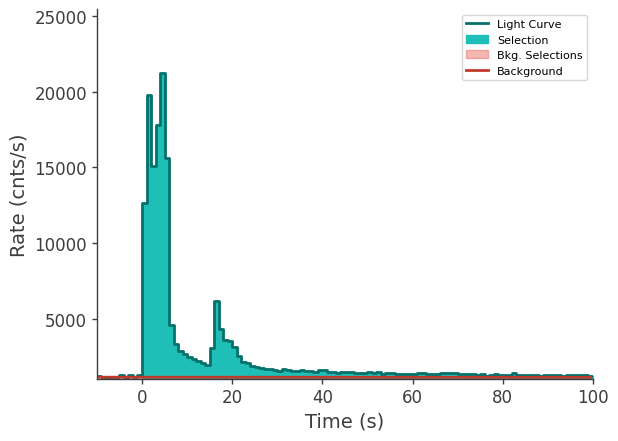

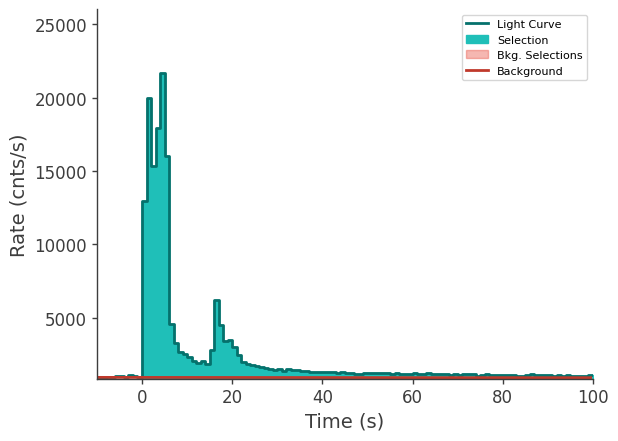

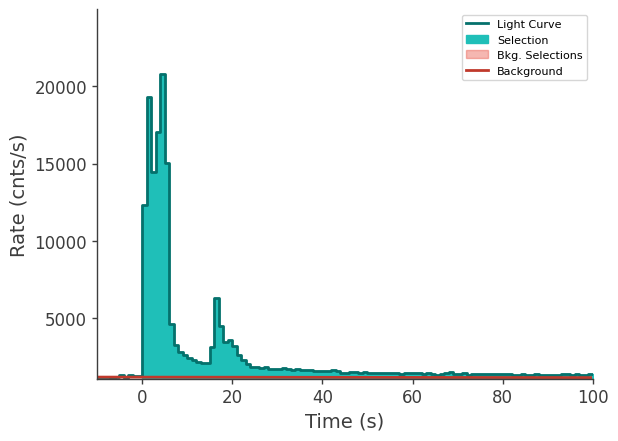

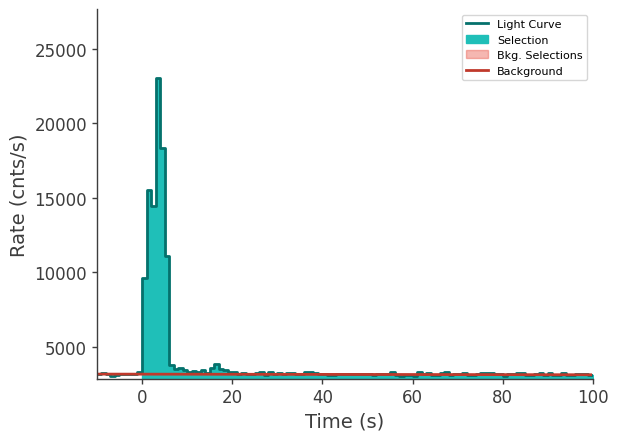

In [8]:
time_series['n3'].view_lightcurve(-10, 100);
time_series['n4'].view_lightcurve(-10, 100);
time_series['n8'].view_lightcurve(-10, 100);
time_series['b0'].view_lightcurve(-10, 100);

## Prepare LAT Low Energy (LLE) data

In [10]:
lle_dload = download_LLE_trigger_data(trigger_name,destination_directory=datadir)

17:54:26 INFO      file gll_cspec_bn190114873_v00.pha is already downloaded!              ]8;id=811146;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=973609;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file gll_cspec_bn190114873_v00.rsp is already downloaded!              ]8;id=102187;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=942942;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

17:54:27 INFO      file gll_lle_bn190114873_v00.fit is already downloaded!                ]8;id=500537;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=818578;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

         INFO      file gll_pt_bn190114873_v00.fit is already downloaded!                 ]8;id=135102;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py\download_from_http.py]8;;\:]8;id=668069;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/io/download_from_http.py#195\195]8;;\

In [11]:
bkg_selection = ["-100--50","150-300"]
emin, emax = 30*u.MeV, 100*u.MeV
lle_time_series = TimeSeriesBuilder.from_lat_lle("lat_lle", lle_file=lle_dload["lle"], ft2_file=lle_dload["ft2"], rsp_file=lle_dload["rsp"]
)
lle_time_series.set_background_interval(*bkg_selection)
lle_time_series.save_background("lle_bkg.h5", overwrite=True)

lle_time_series.set_active_time_interval("%d-%d" % (tstart, tstop))

lle_plugin = lle_time_series.to_spectrumlike()
lle_plugin.set_active_measurements("%d-%d" % (emin.to('keV').value, emax.to('keV').value))
lle_plugin.use_effective_area_correction(0.8, 1.2)

17:54:33 WARNING   The default choice for MATRIX extension failed:KeyError("Extension ('MATRIX', 1) ]8;id=398401;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py\response.py]8;;\:]8;id=991126;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/OGIP/response.py#476\476]8;;\
                  not found.")available: None 'EBOUNDS' 'SPECRESP MATRIX'                                          

Finding best polynomial Order:   0%|                                                                          …

         INFO      Auto-determined polynomial order: 2                                            ]8;id=254126;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/time_series/event_list.py\event_list.py]8;;\:]8;id=308365;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/time_series/event_list.py#538\538]8;;\

Fitting GLAST_LLE background:   0%|                                                                           …

         INFO      None 2-order polynomial fit with the mle method                               ]8;id=117681;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/time_series/time_series.py\time_series.py]8;;\:]8;id=529359;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/time_series/time_series.py#458\458]8;;\

...

         INFO      Auto-probed noise models:                                                    ]8;id=66883;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=593843;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: poisson                                                       ]8;id=65676;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=442273;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: gaussian                                                       ]8;id=491062;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=613405;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      Range 30000-100000 translates to channels 7-16                              ]8;id=111594;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=454680;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#1247\1247]8;;\

         INFO      lat_lle is using effective area correction (between 0.8 and 1.2)            ]8;id=896300;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=333650;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/plugins/SpectrumLike.py#2279\2279]8;;\

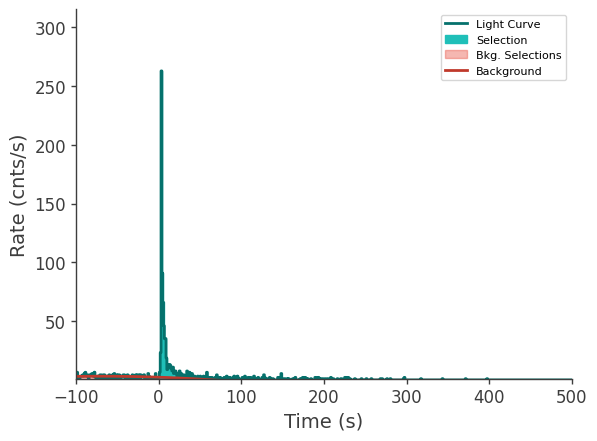

In [12]:
lle_time_series.view_lightcurve(-100, 500);

## Prepare LAT data

In [13]:
LATdataset = LAT_dataset()

LATdataset.make_LAT_dataset(
    ra=ra,
    dec=dec,
    radius=12,
    trigger_time=met,
    tstart=0,
    tstop=1000,
    data_type="Extended",
    destination_directory=datadir,
    Emin=100.0, #100 MeV
    Emax=100000.0, #100 GeV
)

time -p gtmktime scfile=/shared/fermi-data/190114873/bn190114873/gll_ft2_tr_bn190114873_v00.fit sctable="SC_DATA" filter="(DATA_QUAL>0 || DATA_QUAL==-1) && LAT_CONFIG==1 && IN_SAA!=T && LIVETIME>0 && (ANGSEP(RA_ZENITH,DEC_ZENITH,54.51,-26.939)<=(105.0-10))" roicut=no evfile=/shared/fermi-data/190114873/bn190114873/gll_ft1_tr_bn190114873_v00.fit evtable="EVENTS" outfile="gll_ft1_tr_bn190114873_v00_mkt.fit" apply_filter=yes overwrite=no header_obstimes=yes tstart=569192227.629 tstop=569193227.629 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 0.06
user 0.18
sys 0.01

Using 305 data

time -p gtselect infile=gll_ft1_tr_bn190114873_v00_mkt.fit outfile=gll_ft1_tr_bn190114873_v00_filt.fit ra=54.51 dec=-26.939 rad=10.0 tmin=569192227.629 tmax=569193227.629 emin=100.0 emax=100000.0 zmin=0.0 zmax=105.0 evclass=32 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"
Done.
real 0.09
user 0.29
sys 0.02

Selected 199 

17:54:34 INFO      Extracted 199 events                                                    ]8;id=40455;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=841963;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#670\670]8;;\

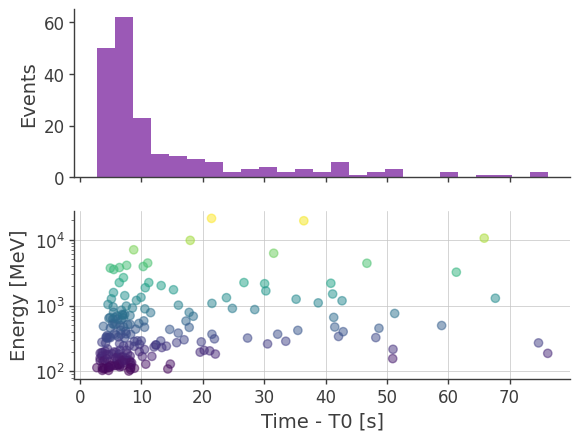

In [14]:
LATdataset.extract_events(roi, zmax, irf)

with fits.open(LATdataset.filt_file) as event_file:
    lat_events = event_file["EVENTS"].data
event_times = lat_events["TIME"] - met

%matplotlib inline
fig, axs = plt.subplots(2, 1, sharex=True)
plt.sca(axs[0])
plt.hist(event_times);
plt.ylabel('Events')
plt.sca(axs[1])
plt.scatter(event_times, lat_events['ENERGY'], marker='o', c=lat_events['ENERGY'], norm='log',
            alpha=0.5, zorder=20);
plt.yscale('log')
plt.ylabel('Energy [MeV]')
plt.xlabel('Time - T0 [s]')
plt.grid(True)
plt.show()

In [15]:
analysis_builder = TransientLATDataBuilder(
    LATdataset.grb_name,
    outfile=LATdataset.grb_name,
    roi=roi,
    tstarts="%d" % tstart,
    tstops="%d" % tstop,
    irf=irf,
    zmax=zmax,
    galactic_model="template",
    particle_model="isotr template",
    datarepository=".",
)
df = analysis_builder.display(get=True)

outfile                      190114873
roi                                 10
tstarts                              0
tstops                             117
zmax                             105.0
emin                             100.0
emax                          100000.0
irf                   p8_transient010e
galactic_model                template
particle_model          isotr template
source_model                 PowerLaw2
tsmin                             20.0
strategy                          time
thetamax                         180.0
spectralfiles                       no
liketype                      unbinned
optimizeposition                    no
datarepository                       .
ltcube                                
expomap                               
ulphindex                           -2
flemin                             100
flemax                           10000
fgl_mode                          fast
filter_GTI                       False
likelihood_profile       

In [16]:
LAT_observations = analysis_builder.run(recompute_intervals=True)
LAT_plugin = LAT_observations[0].to_LATLike()

         INFO      Changing permission to                                              ]8;id=666147;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=890140;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#635\635]8;;\
                  /opt/anaconda/envs/fermi/lib/python3.11/site-packages/fermitools/GtB                             
                  urst/scripts/doTimeResolvedLike.py                                                               

         INFO      About to run the following command:                                 ]8;id=5770;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=465840;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#640\640]8;;\
                  /opt/anaconda/envs/fermi/lib/python3.11/site-packages/fermitools/GtB                             
                  urst/scripts/doTimeResolvedLike.py 190114873 --outfile '190114873'                               
                  --roi 10.000000 --tstarts '0' --tstops '117' --zmax 105.000000                                   
                  --emin 100.000000 --emax 100000.000000 --irf 'p8_transient010e'                                  
                  --galactic_model 'template' --particle_model 'isotr template'                                    
                  --source_model 'PowerLaw2' --tsmin 20.000000 --strategy 'time'                                   
                  --thetamax 180.000000 --spectralfiles 'no' --liketype 'unbinned'                                 
                  --optimizeposition 'no' --datarepository '.' --ltcube '' --expomap                               
                  '' --ulphindex -2.000000 --flemin 100.000000 --flemax 10000.000000                               
                  --fgl_mode 'fast'                                                                                

         INFO      You have choosen to recompute the time intervals in this folder     ]8;id=68056;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=985782;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#654\654]8;;\

         INFO      The older entries will be moved to                                  ]8;id=23900;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=731029;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#658\658]8;;\
                  tmp_bec945ac-a993-4aba-8998-590256dc43bc                                                         

 **********
 **    1 **SET PRINT     .000    
 **********
 **********
 **    2 **SET NOWARN 
 **********

 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 'Integral  '    .10000E-01   1.0000         .10000E-04   1000.0    
     2 'Index     '   -2.0000       1.0000        -6.0000       .10000E-01
     3 'Value     '    1.0000       1.0000         .70000       1.3000    
     4 'Normalizat'    1.0000       1.0000         .10000       10.000    
 **********
 **    3 **SET ERR    .5000    
 **********
 **********
 **    4 **SET GRAD    1.000    
 **********
 **********
 **    5 **MINIMIZE    900.0       2.000    
 **********

 MIGRAD MINIMIZATION HAS CONVERGED.

 MIGRAD WILL VERIFY CONVERGENCE AND ERROR MATRIX.

 FCN=   724.4777     FROM MIGRAD    STATUS=CONVERGED     81 CALLS       82 TOTAL
                     EDM=   .28E-06    STRATEGY= 1      ERROR MATRIX ACCURATE 

  EXT PARAMETER                                   STEP         FIRST   
  NO.   NA

...


Requested intervals:
------------------------------------------------------
0.0                  - 117.0

Data files:
-----------
eventfile            /shared/fermi-data/190114873/bn190114873/gll_ft1_tr_bn190114873_v00.fit
ft2file              /shared/fermi-data/190114873/bn190114873/gll_ft2_tr_bn190114873_v00.fit
rspfile              /shared/fermi-data/190114873/bn190114873/gll_cspec_tr_bn190114873_v00.rsp
cspecfile            /shared/fermi-data/190114873/bn190114873/gll_cspec_tr_bn190114873_v00.pha

ROI:
-----
R.A.                 54.51
Dec.                 -26.939
Radius               10.0

Interval # 1 (0.0-117.0):
-----------------------

-> gtdocountsmap.py rad='10.0' eventfile='/shared/fermi-data/190114873/bn190114873/gll_ft1_tr_bn190114873_v00.fit' zmax='105.0' thetamax='180.0' emin='100.0' emax='100000.0' skymap='190114873_LAT_skymap_0.0-117.0.fit' rspfile='/shared/fermi-data/190114873/bn190114873/gll_cspec_tr_bn190114873_v00.rsp' strategy='time' ft2file='/shared/fermi-data/1

17:55:04 INFO      The ft2 file does not exist. Please examine!                        ]8;id=689926;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=353344;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#726\726]8;;\

         INFO      we will grab the data file for you.                                 ]8;id=790651;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=76740;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#727\727]8;;\

         INFO      copied ./bn190114873/gll_ft2_tr_bn190114873_v00.fit to              ]8;id=681863;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=347524;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#743\743]8;;\
                  interval0.0-117.0/gll_ft2_tr_bn190114873_v00.fit                                                 

FermiLATLike - GTI SUM =  87.97100007534027


## Define the first model to test

In [17]:
band = Band()
band.alpha.prior = Truncated_gaussian(lower_bound=-1.5, upper_bound=1, mu=-1, sigma=0.5)
band.beta.prior = Truncated_gaussian(lower_bound=-5, upper_bound=-1.6, mu=-2, sigma=0.5)
band.xp.prior = Log_normal(mu=2, sigma=1)
band.xp.bounds = (None, None)
band.K.prior = Log_uniform_prior(lower_bound=1e-10, upper_bound=1e3)
source = PointSource(trigger_name, ra, dec, spectral_shape=band)
band_model = Model(source)

17:55:04 WARNING   We have set the min_value of Band.xp to 1e-99 because there was a postive       ]8;id=995508;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=902738;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#704\704]8;;\
                  transform                                                                                        

         WARNING   We have set the min_value of Band.xp to 1e-99 because there was a postive       ]8;id=136590;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=852484;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#704\704]8;;\
                  transform                                                                                        

## Run the joint fit

In [18]:
datalist_1 = DataList(*gbm_plugins, lle_plugin, LAT_plugin)
jl_1 = JointLikelihood(band_model, datalist_1, verbose=False)
band_model.display()
print(jl_1.data_list.keys())
# This is needed to fix the galactic template to 1 (if needed) 
band_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].value = 1.0
band_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].fix = True
band_model[LAT_plugin.get_name() + "_IsotropicTemplate_Normalization"].fix = False
#sbpl_model.display(complete=True)
jl_1.set_minimizer("minuit")
jl_1.fit();


Found Isotropic template for irf P8R3_TRANSIENT010E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT010E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT010E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 



17:55:08 INFO      set the minimizer to minuit                                             ]8;id=131083;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=854480;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (7):
--------------------

                                           value min_value max_value  \
bn190114873.spectrum.main.Band.K          0.0001       0.0      None   
bn190114873.spectrum.main.Band.alpha        -1.0      -1.5       3.0   
bn190114873.spectrum.main.Band.xp          500.0       0.0      None   
bn190114873.spectrum.main.Band.beta         -2.0      -5.0      -1.6   
cons_lat_lle                                 1.0       0.8       1.2   
LAT0X117_GalacticTemplate_Value              1.0       0.5       1.5   
LAT0X117_IsotropicTemplate_Normalization     1.0       0.1       5.0   

                                                    unit  
bn190114873.spectrum.main.Band.K          keV-1 s-1 cm-2  
bn190114873.spectrum.main.Band.alpha                      
bn190114873.spectrum.main.Band.xp                    keV  
bn190114873.spectrum.main.Band.beta                       
cons_lat_lle                                              
LAT0X117_GalacticTemplate_Value                           
LAT0X117_IsotropicTemplate_Normalization                  

Fixed parameters (7):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

odict_keys(['n3', 'n4', 'n8', 'b0', 'lat_lle', 'LAT0X117'])


         INFO      set the minimizer to MINUIT                                             ]8;id=918079;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=743292;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1063\1063]8;;\

...

1.00,0.75,-0.93,0.43,0.00,0.00
0.75,1.00,-0.84,0.34,0.00,0.00
-0.93,-0.84,1.00,-0.50,-0.00,-0.00
0.43,0.34,-0.50,1.00,-0.00,0.00
0.00,0.00,-0.00,-0.00,1.00,-0.00
0.00,0.00,-0.00,0.00,-0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
n3,865.449507
n4,878.260307
n8,893.895597
b0,900.835317
lat_lle,50.978181
LAT0X117,1603.903723
total,5193.322632


Values of statistical measures:

,statistical measures
AIC,10398.786204
BIC,10425.056768



WARNING RuntimeWarning: invalid value encountered in divide



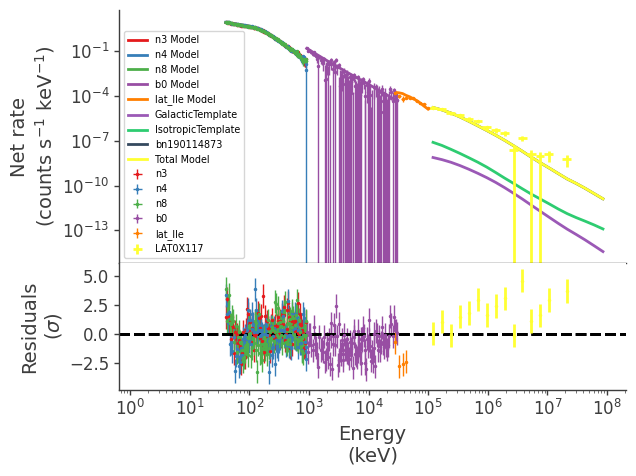

In [19]:
display_spectrum_model_counts(jl_1);

## Define a second model to test

In [20]:
spectrum = Band() + Powerlaw()
# spectrum.K_1 = 0.1
# spectrum.break_energy_1 = 800
# spectrum.beta_1 = -3
# spectrum.K_2 = 3
#spectrum.index_2=-1
source_2 = PointSource("%s_2" % trigger_name, ra, dec, spectral_shape=spectrum)
comp_model = Model(source_2)
comp_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (6):
--------------------

                          value min_value max_value            unit
bn190114873_2...K_1      0.0001       0.0      None  keV-1 s-1 cm-2
bn190114873_2...alpha_1    -1.0      -1.5       3.0                
bn190114873_2...xp_1      500.0      10.0      None             keV
bn190114873_2...beta_1     -2.0      -5.0      -1.6                
bn190114873_2...K_2         1.0       0.0    1000.0  keV-1 s-1 cm-2
bn190114873_2...index_2   -2.01     -10.0      10.0                

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [21]:
datalist_2 = DataList(*gbm_plugins, lle_plugin, LAT_plugin)
jl_2 = JointLikelihood(comp_model, datalist_2, verbose=False)
comp_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].value = 1.0
comp_model[LAT_plugin.get_name() + "_GalacticTemplate_Value"].fix = True
comp_model[LAT_plugin.get_name() + "_IsotropicTemplate_Normalization"].fix = False
jl_2.set_minimizer("minuit")
jl_2.fit();


Found Isotropic template for irf P8R3_TRANSIENT010E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT010E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT010E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 



17:55:13 INFO      set the minimizer to minuit                                             ]8;id=593167;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=598138;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

         INFO      set the minimizer to MINUIT                                             ]8;id=886955;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=75859;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1063\1063]8;;\

17:55:14 WARNING   75.12 percent of samples have been thrown away because they failed the  ]8;id=754811;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=905284;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/analysis_results.py#1739\1739]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

...

1.00,-0.75,0.19,0.28,-0.86,0.70,-0.00,0.00
-0.75,1.00,-0.77,-0.07,0.93,-0.82,0.00,0.00
0.19,-0.77,1.00,-0.20,-0.58,0.55,-0.00,-0.00
0.28,-0.07,-0.20,1.00,-0.05,-0.15,0.01,0.00
-0.86,0.93,-0.58,-0.05,1.00,-0.93,0.00,0.00
0.70,-0.82,0.55,-0.15,-0.93,1.00,0.00,-0.00
-0.00,0.00,-0.00,0.01,0.00,0.00,1.00,-0.00
0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
n3,855.347683
n4,883.775049
n8,871.716368
b0,856.265818
lat_lle,43.714180
LAT0X117,1583.845056
total,5094.664154


Values of statistical measures:

,statistical measures
AIC,10205.570732
BIC,10240.543645



WARNING RuntimeWarning: invalid value encountered in divide



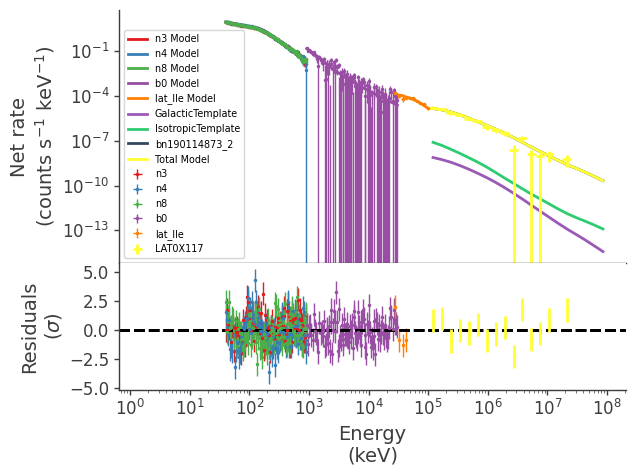

In [22]:
display_spectrum_model_counts(jl_2, show_residuals=True);

### Let's compare the fit statistics (lower is better when comparing two models and adding a component)

In [23]:
jl_1.results.get_statistic_measure_frame()

,statistical measures
AIC,10398.786204
BIC,10425.056768


In [24]:
jl_2.results.get_statistic_measure_frame()

,statistical measures
AIC,10205.570732
BIC,10240.543645


#### The second model is the better fit because it has lower AIC & BIC.

## Plot the two components of the best-fit spectrum 

processing MLE analyses:   0%|                                                                                …

Propagating errors:   0%|                                                                                     …

Propagating errors:   0%|                                                                                     …

Propagating errors:   0%|                                                                                     …

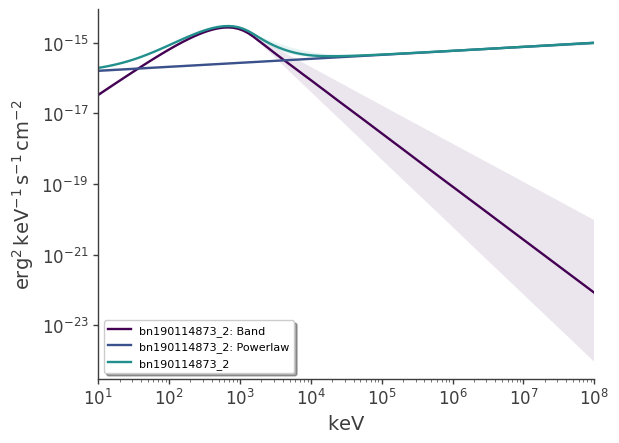

In [25]:
fig = plot_spectra(jl_2.results,
    ene_min=10 * u.keV,
    ene_max=100 * u.GeV,
    flux_unit="erg2/(cm2 s keV)",
    fit_cmap="viridis",
    contour_cmap="viridis",
    contour_style_kwargs=dict(alpha=0.1),
    use_components=True,
    components_to_use = ["total", "Band", "Powerlaw"],
)

## Compute the flux

In [26]:
jl_2.results.get_flux(ene_min=10 * u.keV, ene_max=100 * u.GeV, use_components=True, flux_unit="1/(cm2 s)")

processing MLE analyses:   0%|                                                                                …

,flux,low bound,hi bound
bn190114873_2: Band,10.109687151216423 1 / (s cm2),9.735100053428022 1 / (s cm2),10.487594474066825 1 / (s cm2)
bn190114873_2: Powerlaw,7.414827986085742 1 / (s cm2),6.819520875497048 1 / (s cm2),8.121016196177388 1 / (s cm2)


In [27]:
jl_2.results.get_flux(ene_min=10 * u.keV, ene_max=100 * u.GeV, use_components=False, flux_unit="1/(cm2 s)")

processing MLE analyses:   0%|                                                                                …

,flux,low bound,hi bound
bn190114873_2: total,17.535069907403876 1 / (s cm2),17.281803324437593 1 / (s cm2),17.892919461998503 1 / (s cm2)
